## Import Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Load the dataset:

In [2]:
df = pd.read_csv("DailyClimate_Train.csv")

In [3]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


## Convert date into datetime:

In [5]:
df = pd.read_csv("DailyClimate_Train.csv",index_col="date",parse_dates=True)

In [6]:
df.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [7]:
df.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


> we removed index col and made date as first col so we can get specific month, day & year like this

In [8]:
df.loc["2016"]

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2016-01-01,14.714286,72.285714,1.057143,1021.142857
2016-01-02,14.000000,75.875000,2.087500,1021.000000
2016-01-03,14.375000,74.750000,5.112500,1018.500000
2016-01-04,15.750000,77.125000,0.000000,1017.625000
2016-01-05,15.833333,88.833333,0.616667,1017.000000
...,...,...,...,...
2016-12-27,16.850000,67.550000,8.335000,1017.200000
2016-12-28,17.217391,68.043478,3.547826,1015.565217
2016-12-29,15.238095,87.857143,6.000000,1016.904762


In [9]:
df.loc["2016-03"]

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2016-03-01,24.916667,57.416667,1.700000,1015.000000
2016-03-02,24.933333,57.066667,1.733333,1015.400000
2016-03-03,26.000000,55.615385,4.292308,1014.615385
2016-03-04,27.312500,44.250000,6.143750,1012.687500
2016-03-05,23.933333,57.133333,11.000000,1012.666667
2016-03-06,22.812500,66.562500,5.218750,1013.062500
2016-03-07,23.714286,64.142857,5.171429,1012.357143
2016-03-08,23.428571,60.214286,6.742857,1011.642857
2016-03-09,24.000000,57.562500,9.375000,1012.062500


## Inspecting statistics

In [10]:
df.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


>meanpressure max = 7679 while the normal values are around: 1000–1020
>That's a huge warning sign.

## Plot the time series

<Axes: xlabel='date', ylabel='meantemp'>

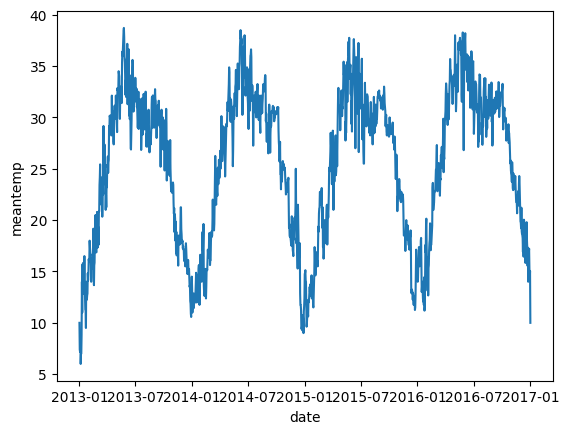

In [21]:
sns.lineplot(df,x="date",
    y="meantemp")

## Plotly:

In [22]:
px.line(x=df.index, y="meantemp", data_frame=df)

In [23]:
df['month'] = df.index.month
df['year'] = df.index.year

***************

# Prophet concept:

In [31]:
df = pd.read_csv("DailyClimate_Train.csv")
df = df.rename( columns={
        'date': 'ds',
        'meantemp': 'y'
    })

>ds → timestamp

>y  → value we're predicting

## Train Prophet:

In [26]:
from prophet import Prophet

In [32]:
model =Prophet()
model.fit(df)

16:27:02 - cmdstanpy - INFO - Chain [1] start processing
16:27:03 - cmdstanpy - INFO - Chain [1] done processing


## Create future dates

In [34]:
forecast = model.make_future_dataframe(periods=365)

## Make predictions:

In [37]:
forecast = model.predict(forecast)
#print(forecast)

## Evaluate:

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
y_true = df['y']
y_pred = forecast["yhat"][:len(df)]

In [42]:
mse =  mean_absolute_error(y_true, y_pred)

In [43]:
mse

1.599604102157497

#### RMSE

In [44]:
rmse = np.sqrt(mse)

## Prophet components

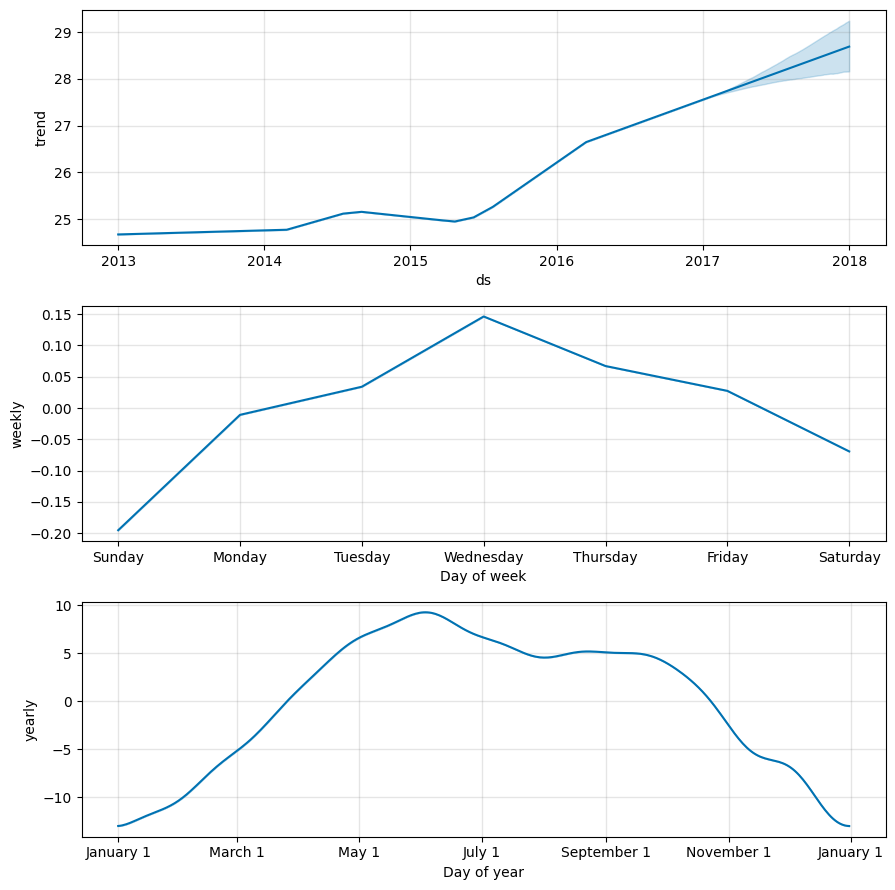

In [45]:
fig = model.plot_components(forecast)

## Changepoints:

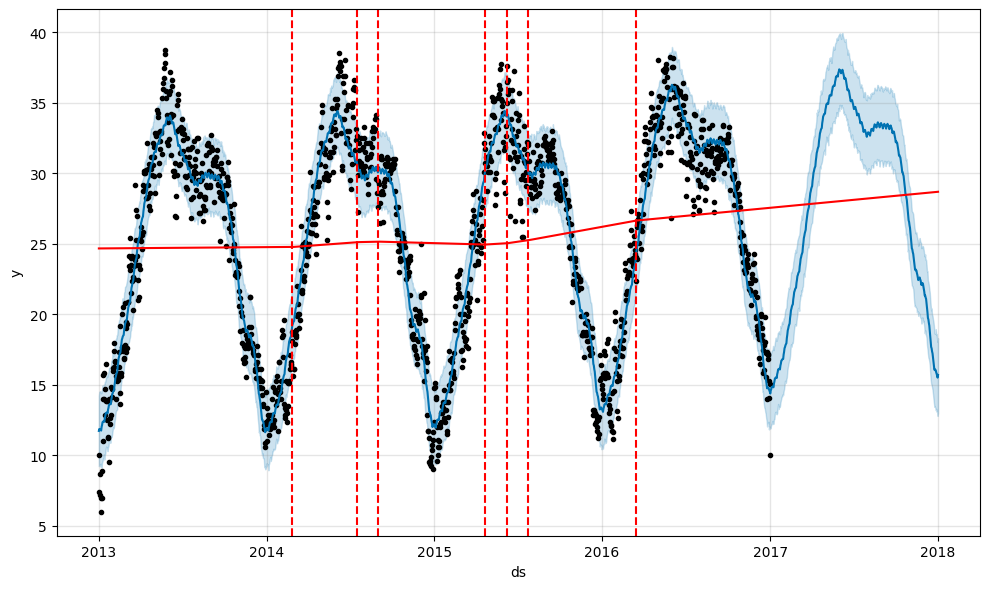

In [46]:
from prophet.plot import add_changepoints_to_plot
fig = model.plot(forecast)
a = add_changepoints_to_plot(fig.gca(),model,forecast)

## Plotly:

In [51]:
import plotly.graph_objects as go

fig = go.Figure()

# Actual values
fig.add_trace(go.Scatter(
    x=df["ds"],
    y=df["y"],
    mode="markers",
    name = "Actual"
))
# Forecast
fig.add_trace(go.Scatter(
    x=forecast["ds"],
    y=forecast["yhat"],
    mode="lines",
    name="Forecast"
))

# Uncertainty interval
fig.add_trace(go.Scatter(
    x=forecast["ds"],
    y=forecast["yhat_upper"],
    mode="lines",
    line=dict(width=0),
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=forecast["ds"],
    y=forecast["yhat_lower"],
    mode="lines",
    fill="tonexty",
    line=dict(width=0),
    name="Uncertainty"
))

fig.show()

## Tuning Prophet:

In [47]:
model = Prophet(changepoint_prior_scale=0.5,
                seasonality_prior_scale=0.1,
                holidays_prior_scale=0.1)

In [48]:
model.add_seasonality(name="monthly",
                      period=30.5,
                      fourier_order=5)